# Testing New Ephemeris and SPICE loading

In [194]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [195]:
import pandas as pd
import numpy as np
import spiceypy as spice
import matplotlib.pyplot as plt

In [196]:
from contigo.solar_system_ephem import SPICEEphem
from contigo.solar_system_ephem import SolarSystemEnvironment
from contigo.forces.third_body_acc import ThirdBodyAcc
from contigo.forces.tba_utils import tba_pairwise_numba

### Test loading ephem with old version of loading ephem

In [197]:
SPICEEphem()

INFO:Kernel already loaded - D:\GitHub\contigo_edr\contigo\data\de440s.bsp
INFO:Kernel already loaded - D:\GitHub\contigo_edr\contigo\data\naif0012.tls
INFO:Kernel already loaded - D:\GitHub\contigo_edr\contigo\data\earth_latest_high_prec.bpc


In [205]:
sw_e = pd.read_hdf("./data/ESA_pod.hdf")

In [199]:
body = ['SUN','MOON']

j2000 = pd.Timestamp('2000-01-01 12:00:00')
spj2000 = ((sw_e['DateTime'] - j2000).dt.total_seconds()).to_list()

# set all needed attributes
et = np.array([spice.unitim(sp_in,'GPS','ET') for sp_in in spj2000])

unique_et, inv = np.unique(et, return_inverse=True)

# get the body positions in ecef
bd_ecef = np.array([spice.spkpos(bd,unique_et,'ITRF93','NONE','EARTH')[0]
            for bd in body])

bd_full = bd_ecef[:,inv,:]

In [215]:
%%timeit
j2000 = pd.Timestamp('2000-01-01 12:00:00')
spj2000 = ((sw_e['DateTime'] - j2000).dt.total_seconds()).to_list()
#spj2000.extend(spj2000)

# set all needed attributes
et = np.array([spice.unitim(sp_in,'GPS','ET') for sp_in in spj2000])

288 ms ± 2.82 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [212]:
len(spj2000)

138240

In [200]:
et[0]

np.float64(568123251.1839513)

In [204]:
print(spice.et2utc(et,'C',3))
print(sw_e['DateTime'][0])

['2018 JAN 01 23:59:42.000' '2018 JAN 01 23:59:52.000'
 '2018 JAN 02 00:00:02.000' ... '2018 JAN 17 23:59:12.000'
 '2018 JAN 17 23:59:22.000' '2018 JAN 17 23:59:32.000']
2018-01-02 00:00:00


In [113]:
x = SPICEEphem()

INFO:Kernel already loaded - D:\GitHub\contigo_edr\contigo\data\de440s.bsp
INFO:Kernel already loaded - D:\GitHub\contigo_edr\contigo\data\naif0012.tls
INFO:Kernel already loaded - D:\GitHub\contigo_edr\contigo\data\earth_latest_high_prec.bpc


In [114]:
c_et, c_bd = x(body=['SUN','MOON'], et=et)

In [115]:
np.array_equal(c_bd,bd_full)

True

### Test new Solar System Environement Class

SolarSystemEnvironment loads and caches ephemeris data with a time tolerance to save
on loading the same ephemeris data over and over.

In [116]:
env = SolarSystemEnvironment(['SUN','MOON'], et=et[0:500], tolerance=0.1,provider=x)

In [117]:
r_et, r_pos = env.get_ephem(et[0:500])
print(r_et.shape)
print(r_pos.shape)

(500,)
(2, 500, 3)


In [118]:
r_et, r_pos = env.get_ephem(et)
print(r_et.shape)
print(r_pos.shape)

(138240,)
(2, 138240, 3)


#### Use ```get_ephem``` to add more ephem

In [133]:
r_pos[id_max]

np.float64(1.1531943783174938)

(138240,)
(2, 138240, 3)
False
1.1531943783174938
0.7278425566657631


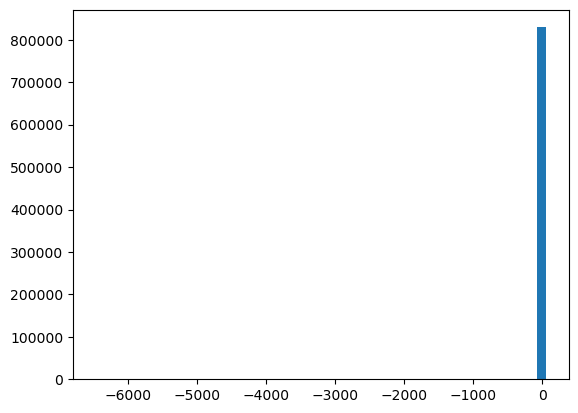

In [132]:
r_et, r_pos = env.get_ephem(et)
print(r_et.shape)
print(r_pos.shape)
print(np.array_equal(r_pos, bd_full))

perc_err = 100*(r_pos.flatten()-bd_full.flatten())/bd_full.flatten()
id_max = np.unravel_index(perc_err.argmax(), r_pos.shape)

print(r_pos[id_max])
print(bd_full[id_max])

_ = plt.hist(perc_err,bins=50)

### Test Thirdbody Calculations and Look at error

In [176]:
spos = sw_e[['x','y','z']].to_numpy()
stime = sw_e['DateTime']
x = sw_e['x'].to_numpy()
y = sw_e['y'].to_numpy()
z = sw_e['z'].to_numpy()
tba_cont = ThirdBodyAcc(spos=spos,stime=stime,body=['SUN','MOON'],scale='GPS')  
tba_cont.calc_tba()

tba_acc = tba_cont.get_tba()
print(tba_acc.shape)

INFO:Kernel already loaded - D:\GitHub\contigo_edr\contigo\data\de440s.bsp
INFO:Kernel already loaded - D:\GitHub\contigo_edr\contigo\data\naif0012.tls
INFO:Kernel already loaded - D:\GitHub\contigo_edr\contigo\data\earth_latest_high_prec.bpc


(2, 138240, 3)


In [185]:
ephem_provider = SPICEEphem()
env = SolarSystemEnvironment(['SUN','MOON'], et=et, tolerance=None,provider=ephem_provider)
r_et, r_pos = env.get_ephem(et)
bd_acc = tba_pairwise_numba(spos, r_pos, tba_cont.GM)
print(bd_acc.shape)

INFO:Kernel already loaded - D:\GitHub\contigo_edr\contigo\data\de440s.bsp
INFO:Kernel already loaded - D:\GitHub\contigo_edr\contigo\data\naif0012.tls
INFO:Kernel already loaded - D:\GitHub\contigo_edr\contigo\data\earth_latest_high_prec.bpc


(2, 138240, 3)


In [186]:
%%timeit
r_et, r_pos = env.get_ephem(et)

34.3 ms ± 513 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [180]:
print(bd_acc[1,0,:])
print(tba_acc[1,0,:])

[-1.81861563e-10  7.29546172e-10  5.87371096e-11]
[-1.81861563e-10  7.29546172e-10  5.87371096e-11]


-9.005938675805368e-11
-9.17306582015673e-11
597852.4907241884


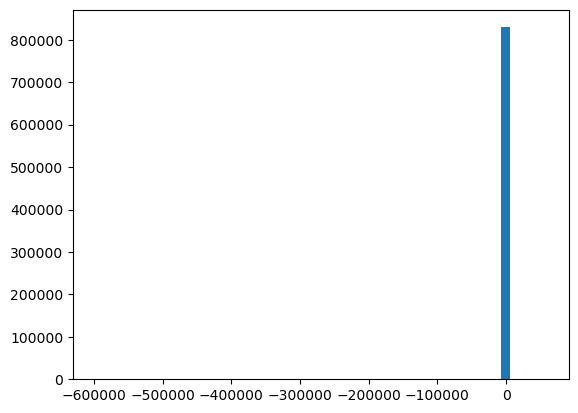

In [163]:
print(tba_acc[0,0,0])
print(bd_acc[0,0,0])

perc_err = 100*(bd_acc.flatten()-tba_acc.flatten())/tba_acc.flatten()
print(np.abs(perc_err).max())
_ = plt.hist(perc_err,bins=50)

In [140]:
id_max = np.unravel_index(perc_err.argmax(), bd_acc.shape)

In [141]:
print(bd_acc[id_max])
print(tba_acc[id_max])


-6.161351064102871e-15
-5.758962466842267e-15


In [159]:
et = np.array([spice.unitim(sp_in,'GPS','TAI') for sp_in in spj2000])
et[0]

np.float64(568123219.0)

In [160]:
spj2000[0]-et[0]

np.float64(-19.0)

In [187]:
# 2. Define your UTC time
utc_time = '2025-08-03T20:25:42'

# 3. Convert UTC to Ephemeris Time (ET/TDB)
et = spice.str2et(utc_time)

# 4. Convert ET to GPS time
gps_time = spice.unitim(et, 'ET', 'GPS')

print(f"UTC: {utc_time}")
print(f"GPS seconds past 1980-01-06 00:00:00: {gps_time}")

UTC: 2025-08-03T20:25:42
GPS seconds past 1980-01-06 00:00:00: 807524760.0


In [188]:
spice.et2utc(et[0])

TypeError: 'float' object is not subscriptable

'2025 AUG 03 20:25:42.000'

In [193]:
et

807524811.1832012